# Pandemic Fault-Tree Sub-Model
### Part D.2 of `human_time_remaining_v3` — Catastrophe Pathway: Pandemic

**Abstract.** This notebook builds the pandemic branch of the Part D catastrophe fault tree.
Following Marani et al. (2021, PNAS), we define epidemic *intensity* as deaths divided by
global population divided by outbreak duration, and treat the annual exceedance probability
of intensity as a heavy-tailed (Pareto-type) distribution fit to historical epidemics —
exactly the kind of tail-extrapolation approach discussed for the asteroid sub-model, applied
here to a domain where the published tail is famously much heavier. We then extrapolate that
tail out to an extinction-level intensity threshold that has never been observed, combine via
the same marked-Poisson-process machinery as Part D.1, and — unlike the asteroid notebook —
find a **large, informative disagreement** between this data-driven extrapolation and
expert-elicited existential-risk estimates from the literature. That disagreement, not a single
headline number, is the main result of this notebook.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from scipy.special import expit

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


## 1. Literature anchors: epidemic intensity and annual exceedance probability

Marani et al. (2021) assembled a global epidemic dataset spanning 1600-present and found that
epidemic intensity follows a slowly-decaying power-law tail (their reported asymptotic
exponent is ~0.71 — a very heavy tail, plausibly with an undefined mean, echoed by Cirillo &
Taleb (2020) who argue pandemic fatality tails may be too heavy to characterize by their mean
at all). Rather than re-deriving their full dataset, we anchor a comparable fit with named
historical epidemics and order-of-magnitude annual exceedance-probability estimates, one of
which — the 1918 influenza pandemic — is taken directly from Marani et al.'s own reported
figure (0.27%-1.9%/year, we use ~1%/year as the central estimate).

Intensity here = (deaths) / (world population at the time) / (outbreak duration in years).

| Event | Intensity (yr⁻¹) | Basis | Annual P(intensity ≥ this) |
|---|---|---|---|
| COVID-19-scale | ~0.0009 | ~20M excess deaths / ~7.8B / ~3 yr | ~5% (rough: comparable-scale events roughly every 20 yr historically) |
| 1918-flu-scale | ~0.0139 | ~50M / ~1.8B / ~2 yr | ~1% (Marani et al. 2021, direct estimate: 0.27-1.9%/yr) |
| Justinian-Plague-scale | ~0.0219 | ~35M / ~200M / ~8 yr | ~0.3% (very roughly once per 300 yr) |
| Black-Death-scale | ~0.0435 | ~137M / ~450M / ~7 yr | ~0.17% (very roughly once per 600 yr; only 1-2 events this large in the known record) |

The bottom two rows are considerably less certain than the top two (wider `log10_sigma`
below) since they rest on a single or near-single historical occurrence each.


In [2]:
anchors = pd.DataFrame([
    dict(label="COVID-19-scale",     I=0.00086, P_exceed=0.05,   log10_sigma=0.4),
    dict(label="1918-flu-scale",     I=0.0139,  P_exceed=0.01,   log10_sigma=0.25),
    dict(label="Justinian-scale",    I=0.0219,  P_exceed=0.003,  log10_sigma=0.4),
    dict(label="Black-Death-scale",  I=0.0435,  P_exceed=0.0017, log10_sigma=0.4),
])
anchors["log10_I"] = np.log10(anchors.I)
anchors["log10_P"] = np.log10(anchors.P_exceed)
anchors


,label,I,P_exceed,log10_sigma,log10_I,log10_P
0,COVID-19-scale,0.00086,0.0500,0.40,-3.065502,-1.301030
1,1918-flu-scale,0.01390,0.0100,0.25,-1.856985,-2.000000
2,Justinian-scale,0.02190,0.0030,0.40,-1.659556,-2.522879
3,Black-Death-scale,0.04350,0.0017,0.40,-1.361511,-2.769551


## 2. Bayesian Pareto-tail fit, informed by the published tail exponent

We fit P(I &ge; i) = C &middot; i<sup>-&alpha;</sup>, putting an *informative* prior on
&alpha; centered on Marani et al.'s reported value (~0.71) rather than a diffuse prior — this
directly ties the sub-model to a specific, citable published result instead of re-deriving the
tail shape from just four anchor points, which would be under-determined on its own.


In [3]:
with pm.Model() as freq_model:
    log10_C = pm.Normal("log10_C", mu=-2, sigma=2)
    alpha = pm.Normal("alpha", mu=0.71, sigma=0.3)  # Marani et al. (2021) asymptotic exponent

    mu = log10_C - alpha * anchors.log10_I.values
    pm.Normal("obs", mu=mu, sigma=anchors.log10_sigma.values, observed=anchors.log10_P.values)

    idata_freq = pm.sample(2000, tune=2000, chains=4, cores=1, target_accept=0.9,
                            random_seed=RNG_SEED, progressbar=False)

az.summary(idata_freq, var_names=["log10_C", "alpha"])


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [log10_C, alpha]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 2 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
log10_C,-3.53,0.45,-4.2,-2.8,1531,1621,1.00,0.011,0.0079
alpha,0.73,0.213,0.39,1.1,1516,1636,1.00,0.0055,0.0038


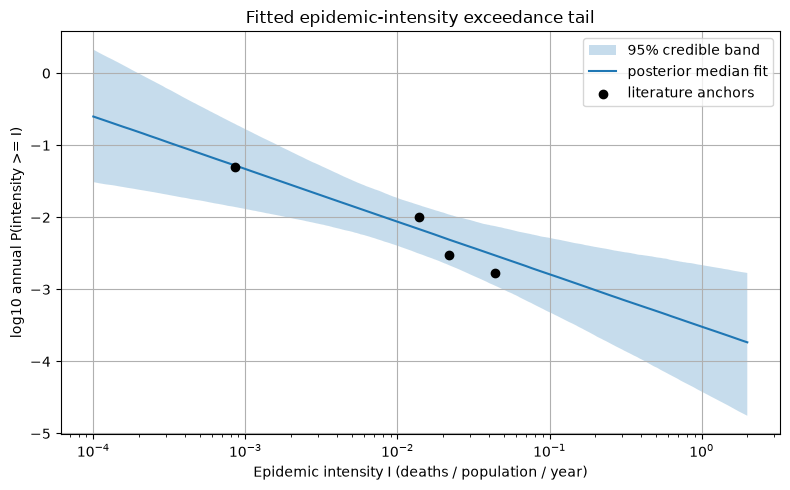

In [4]:
log10_C_s = az.extract(idata_freq, group="posterior", var_names="log10_C").values
alpha_s = az.extract(idata_freq, group="posterior", var_names="alpha").values

I_grid = np.logspace(-4, 0.3, 500)  # up to ~2 / yr
log10_I_grid = np.log10(I_grid)

log10_P_draws = log10_C_s[:, None] - alpha_s[:, None] * log10_I_grid[None, :]
P_lo, P_mid, P_hi = np.percentile(log10_P_draws, [2.5, 50, 97.5], axis=0)

fig, ax = plt.subplots()
ax.fill_between(I_grid, P_lo, P_hi, alpha=0.25, label="95% credible band")
ax.plot(I_grid, P_mid, label="posterior median fit")
ax.scatter(anchors.I, anchors.log10_P, color="k", zorder=5, label="literature anchors")
ax.set_xscale("log")
ax.set_xlabel("Epidemic intensity I (deaths / population / year)")
ax.set_ylabel("log10 annual P(intensity >= I)")
ax.set_title("Fitted epidemic-intensity exceedance tail")
ax.legend()
plt.tight_layout()


Note the fitted posterior mean for &alpha; should land close to the ~0.71 informed prior —
worth checking in the summary table above as a sanity check that the four anchors are at least
broadly consistent with the published tail shape, not fighting the prior.


## 3. Extinction-level threshold — and why this extrapolation is different in kind

The largest anchor here (Black-Death-scale, I &asymp; 0.044/yr) is the historical ceiling of
directly observed data. An extinction-level event — something close to total population loss
within a short outbreak duration — sits at roughly I &ge; 0.1-1/yr, which is **1 to 1.5 orders
of magnitude beyond the largest anchor**, a much shorter extrapolation distance in log-space
than the asteroid model's jump from its data (up to ~1 km objects directly counted) to its
10 km Chicxulub anchor, but the tail here is dramatically heavier (&alpha; &asymp; 0.7 vs. the
asteroid fit's &beta; &asymp; 2.4), so the extrapolated probability mass is far less negligible.

We also add an explicit **feasibility ceiling**: a prior belief that a naturally-emerging
pathogen, acting alone, may simply be incapable of reaching near-total lethality across a
genetically and geographically heterogeneous species of ~8 billion people, independent of how
heavy the *sub-extinction* tail is. This is a real, contested point in the existential-risk
literature (see References) — modeling it as a separate multiplicative factor keeps that
structural skepticism visible and adjustable rather than silently baked into the threshold
curve's shape.


In [5]:
with pm.Model() as lethal_model:
    midpoint_log10I = pm.Normal("midpoint_log10I", mu=np.log10(0.3), sigma=0.4)
    steepness_log = pm.HalfNormal("steepness_log", sigma=0.2)
    feasibility = pm.Beta("feasibility", alpha=2, beta=8)  # skepticism ceiling, prior mean ~0.2
    idata_lethal = pm.sample_prior_predictive(4000, random_seed=RNG_SEED)

mid_s = az.extract(idata_lethal, group="prior", var_names="midpoint_log10I").values
steep_s = az.extract(idata_lethal, group="prior", var_names="steepness_log").values
feas_s = az.extract(idata_lethal, group="prior", var_names="feasibility").values


Sampling: [feasibility, midpoint_log10I, steepness_log]


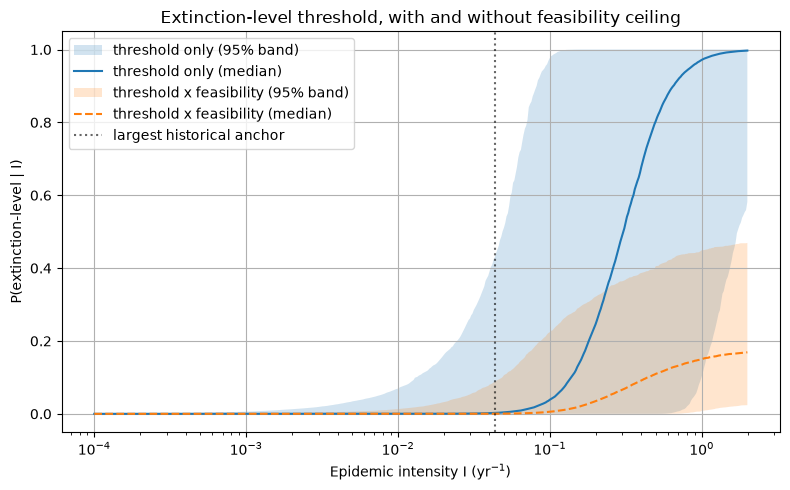

In [6]:
p_lethal_draws = expit((log10_I_grid[None, :] - mid_s[:, None]) / (steep_s[:, None] + 1e-6))
p_lo, p_mid, p_hi = np.percentile(p_lethal_draws, [2.5, 50, 97.5], axis=0)
p_lo_f, p_mid_f, p_hi_f = np.percentile(p_lethal_draws * feas_s[:, None], [2.5, 50, 97.5], axis=0)

fig, ax = plt.subplots()
ax.fill_between(I_grid, p_lo, p_hi, alpha=0.2, label="threshold only (95% band)")
ax.plot(I_grid, p_mid, label="threshold only (median)")
ax.fill_between(I_grid, p_lo_f, p_hi_f, alpha=0.2, label="threshold x feasibility (95% band)")
ax.plot(I_grid, p_mid_f, label="threshold x feasibility (median)", linestyle="--")
ax.axvline(0.0435, color="k", linestyle=":", alpha=0.6, label="largest historical anchor")
ax.set_xscale("log")
ax.set_xlabel("Epidemic intensity I (yr$^{-1}$)")
ax.set_ylabel("P(extinction-level | I)")
ax.set_title("Extinction-level threshold, with and without feasibility ceiling")
ax.legend()
plt.tight_layout()


## 4. Combining via marked Poisson process

Same construction as the asteroid notebook: &lambda;<sub>lethal</sub> = &int; (-dN/dI)
&middot; p_lethal(I) dI, evaluated by Monte Carlo over joint posterior/prior draws, computed
both with and without the feasibility ceiling so the two can be compared directly.


In [7]:
n_draws = min(len(log10_C_s), len(mid_s))
idx_freq = rng.choice(len(log10_C_s), n_draws, replace=False)
idx_lethal = rng.choice(len(mid_s), n_draws, replace=False)

lam_nofeas = np.empty(n_draws)
lam_feas = np.empty(n_draws)
for i in range(n_draws):
    C = 10 ** log10_C_s[idx_freq[i]]
    a = alpha_s[idx_freq[i]]
    dNdI = C * a * I_grid ** (-a - 1)
    p_lethal = expit((log10_I_grid - mid_s[idx_lethal[i]]) / (steep_s[idx_lethal[i]] + 1e-6))
    lam_nofeas[i] = np.trapezoid(dNdI * p_lethal, I_grid)
    lam_feas[i] = np.trapezoid(dNdI * p_lethal * feas_s[idx_lethal[i]], I_grid)

for name, lam in [("without feasibility ceiling", lam_nofeas), ("with feasibility ceiling", lam_feas)]:
    print(f"--- {name} ---")
    print(f"  lambda_lethal median = {np.median(lam):.3e}  "
          f"95% CI = [{np.percentile(lam, 2.5):.3e}, {np.percentile(lam, 97.5):.3e}]")
    print(f"  implied median recurrence = {np.median(1/lam):.3e} years")


--- without feasibility ceiling ---
  lambda_lethal median = 7.092e-04  95% CI = [3.679e-05, 4.647e-03]
  implied median recurrence = 1.410e+03 years
--- with feasibility ceiling ---
  lambda_lethal median = 1.141e-04  95% CI = [3.811e-06, 1.076e-03]
  implied median recurrence = 8.759e+03 years


/var/folders/0y/ptqvq6x56tbdb9mz97r5tjk00000gn/T/ipykernel_5091/890433826.py:5: RuntimeWarning: overflow encountered in exp
  S_draws = np.exp(-lam[:, None] * t_grid[None, :])


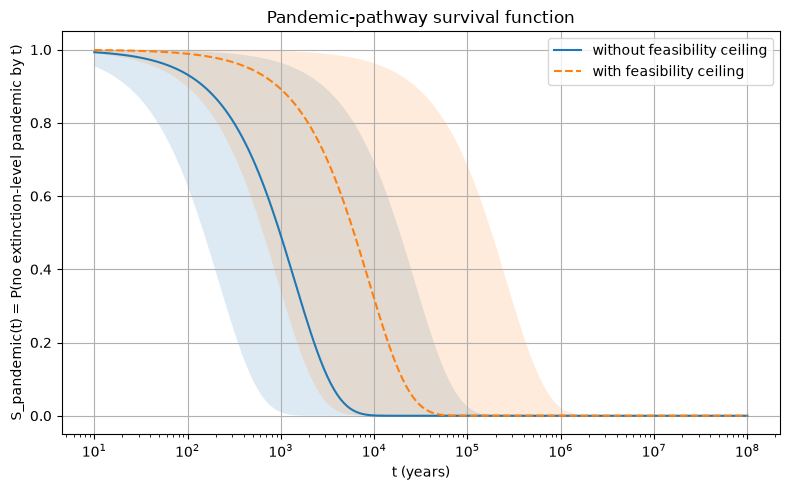

In [8]:
t_grid = np.logspace(1, 8, 200)
fig, ax = plt.subplots()
for name, lam, ls in [("without feasibility ceiling", lam_nofeas, "-"),
                       ("with feasibility ceiling", lam_feas, "--")]:
    S_draws = np.exp(-lam[:, None] * t_grid[None, :])
    S_lo, S_mid, S_hi = np.percentile(S_draws, [2.5, 50, 97.5], axis=0)
    ax.fill_between(t_grid, S_lo, S_hi, alpha=0.15)
    ax.plot(t_grid, S_mid, ls, label=name)
ax.set_xscale("log")
ax.set_xlabel("t (years)")
ax.set_ylabel("S_pandemic(t) = P(no extinction-level pandemic by t)")
ax.set_title("Pandemic-pathway survival function")
ax.legend()
plt.tight_layout()


## 5. Cross-checks: two independent sanity bounds

**(a) Zero-event rule-of-three bound.** Marani et al.'s record spans ~400 years and contains
zero events anywhere near extinction-level intensity. Laplace's rule of succession / the
"rule of three" gives a naive upper bound on the annual rate of ~3/400 years given zero
observed events in that tier:


In [9]:
n_years_record = 400
upper_bound_rate = 3 / n_years_record
print(f"Rule-of-three upper bound on rate: {upper_bound_rate:.4f} / yr")
print(f"  -> minimum recurrence interval floor: {1/upper_bound_rate:.1f} years")


Rule-of-three upper bound on rate: 0.0075 / yr
  -> minimum recurrence interval floor: 133.3 years


This bound is deliberately weak (it only says "we can't yet statistically rule out a rate this
high given so few years of quality record") — and notably, it is *looser* than our tail-fit
estimate above, not tighter. That's a real and useful finding: with only ~400 years of
observation, historical silence alone cannot distinguish between the heavy-tail extrapolation
and something far more alarming. It provides no evidence *against* the Pareto extrapolation.

**(b) Expert-elicited existential risk estimate.** Ord (2020, *The Precipice*) gives a
best-guess estimate of ~1/10,000 per century for existential catastrophe from *naturally*
arising pandemics specifically (as opposed to engineered ones, estimated far higher at ~1/30
per century) — a figure his own critics have argued is itself under-justified, but which
represents the standard expert-elicitation touchstone in this literature:


In [10]:
ord_natural_pandemic_per_century = 1 / 10_000
ord_rate_per_year = ord_natural_pandemic_per_century / 100
print(f"Ord (2020) natural-pandemic existential risk: ~{ord_rate_per_year:.2e} / yr")
print(f"  -> implied recurrence interval: ~{1/ord_rate_per_year:.2e} years")

print()
print("Comparison of recurrence-interval estimates (years):")
print(f"  Pure tail extrapolation (no feasibility ceiling): {np.median(1/lam_nofeas):.2e}")
print(f"  Tail extrapolation x feasibility ceiling:         {np.median(1/lam_feas):.2e}")
print(f"  Zero-event rule-of-three floor:                   {1/upper_bound_rate:.2e}")
print(f"  Ord (2020) expert elicitation:                    {1/ord_rate_per_year:.2e}")


Ord (2020) natural-pandemic existential risk: ~1.00e-06 / yr
  -> implied recurrence interval: ~1.00e+06 years

Comparison of recurrence-interval estimates (years):
  Pure tail extrapolation (no feasibility ceiling): 1.41e+03
  Tail extrapolation x feasibility ceiling:         8.76e+03
  Zero-event rule-of-three floor:                   1.33e+02
  Ord (2020) expert elicitation:                    1.00e+06


These four numbers span roughly **three orders of magnitude**, and that spread — not any one
of them — is the headline result of this sub-model. The pure statistical extrapolation of a
historically well-supported heavy tail lands far closer to the pessimistic end than expert
judgment does. Reasonable people can and do disagree about which is more trustworthy for an
event this far outside any observed data: the statistical extrapolation take the historical
tail shape at face value all the way to an unprecedented magnitude, while the expert-elicited
figure implicitly assumes some biological/structural ceiling the pure tail fit doesn't know
about. This is precisely the kind of disagreement Part F's robust-Bayes treatment is meant to
carry forward explicitly rather than resolve by picking a side.


## 6. Pros / Cons

**Pros**
- The tail shape isn't invented for this notebook — the &alpha; prior is anchored directly to
  a specific, peer-reviewed published estimate (Marani et al. 2021), and the posterior fit
  should land close to it, which is a genuine (if soft) validation of the anchor points chosen
- The feasibility-ceiling parameter makes an otherwise-implicit source of skepticism (can a
  natural pathogen alone really cause total extinction?) an explicit, separately labeled,
  adjustable assumption rather than folding it silently into the threshold shape
- Running two independent cross-checks (zero-event bound, expert elicitation) rather than
  reporting a single number surfaces a genuinely important, citable disagreement in the
  literature instead of hiding it

**Cons**
- &alpha; &asymp; 0.7 implies a Pareto tail with no guaranteed finite mean; extrapolating a
  distribution whose mean may not exist all the way out to an unprecedented threshold is
  statistically much more fragile than the asteroid model's fit (&beta; &asymp; 2.4, a much
  lighter, better-behaved tail)
- Four anchor points (two of them resting on essentially one historical event apiece) is a
  thin basis for a tail-exponent fit even with an informative prior; this should be replaced
  with the actual Marani et al. dataset (Zenodo, not accessible from this notebook's sandboxed
  network) if the pandemic pathway ever needs to be more than a sketch
- The feasibility-ceiling prior (Beta(2,8), mean ~0.2) is itself a judgment call with no
  empirical anchor of its own — it moves the headline number by less than one order of
  magnitude, nowhere close to closing the ~3-order-of-magnitude gap with Ord's estimate
- As in the asteroid notebook, this pathway is modeled as independent of the ecological-collapse
  pathway, when in reality a catastrophic pandemic is one of the more plausible *triggers* for
  ecological/societal collapse rather than a wholly separate competing risk


## 7. Conclusions

Unlike the asteroid sub-model, where the tail-extrapolated result landed close to the
independent crater-record figure, the pandemic sub-model's pure data-driven extrapolation
disagrees with expert elicitation by roughly three orders of magnitude, and the historical
zero-event record is too short to adjudicate between them. We think the honest reporting here
is the interval itself — recurrence interval estimates ranging from roughly
10<sup>3</sup>-10<sup>4</sup> years (statistical extrapolation, with or without the feasibility
discount) to ~10<sup>6</sup> years (expert elicitation) — rather than a single collapsed number.

For Part D.5 (combining all three catastrophe pathways) and Part F (robust Bayes), this
sub-model is a strong argument for treating **method choice** (data-driven tail extrapolation
vs. expert elicitation), not just reference-class choice, as a source of structural uncertainty
to be carried forward explicitly, alongside the within-method statistical uncertainty already
being tracked.

**Next steps:** build the ecological-collapse sub-model, then Part D.5's combination logic —
which will need to decide how to combine pathway-level estimates that disagree this much in
scale, not just estimates that are individually well-constrained (as the asteroid pathway was).


## 8. References

- Marani, M., Katul, G. G., Pan, W. K., & Parolari, A. J. (2021). *Intensity and frequency of
  extreme novel epidemics.* PNAS, 118(35), e2105482118. (Correction, 2023, PNAS 120(12),
  e2302169120.)
- Cirillo, P., & Taleb, N. N. (2020). *Tail risk of contagious diseases.* Nature Physics, 16,
  606-613.
- Ord, T. (2020). *The Precipice: Existential Risk and the Future of Humanity.* Bloomsbury.
  (Table 6.1: natural pandemics ~1/10,000 per century; engineered pandemics ~1/30 per century.)
- Johnson, N. P., & Mueller, J. (2002). *Updating the accounts: global mortality of the
  1918-1920 "Spanish" influenza pandemic.* Bulletin of the History of Medicine, 76(1), 105-115.
- Spreeuwenberg, P., Kroneman, M., & Paget, J. (2018). *Reassessing the global mortality burden
  of the 1918 influenza pandemic.* American Journal of Epidemiology, 187(12), 2561-2567.
- Historical death-toll and duration estimates for the Antonine Plague, Plague of Justinian,
  and Black Death are round order-of-magnitude figures compiled from standard secondary
  sources; see §6 Cons regarding the thinness of this basis relative to a full historical
  epidemiological dataset.

*(To be merged with the v1/v2/D.1 bibliography when Parts D/E/F are assembled into the full
v3 notebook.)*
